Feature importance answers the question:

**"What actually drives electricity prices in your model?"** 

We'll use two methods — XGBoost's built-in importance first, then SHAP which is significantly more powerful.

In [1]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')

import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data and trained model
# v2 = 4-year (2021-2024) feature matrix; xgb_lmp_v1.json is the model trained
# in notebook 03 on 2022-2023. SHAP is computed on the 2024 holdout below.
df = pd.read_csv(
    'data/features/feature_matrix_v2.csv',
    parse_dates=['Time'],
    index_col='Time'
)

TARGET   = 'LMP'
FEATURES = [col for col in df.columns if col not in [
    'LMP', 'Energy', 'Congestion', 'Loss'
]]

X = df[FEATURES]
y = df[TARGET]

# Load saved model
model = xgb.XGBRegressor()
model.load_model('models/xgb_lmp_v1.json')

# Use test set for SHAP analysis
X_test = X[X.index >= '2024-01-01']
y_test = y[y.index >= '2024-01-01']

print(f"Features: {len(FEATURES)}")
print(f"Test rows: {len(X_test):,}")
print("Model loaded successfully")

Features: 33
Test rows: 8,784
Model loaded successfully


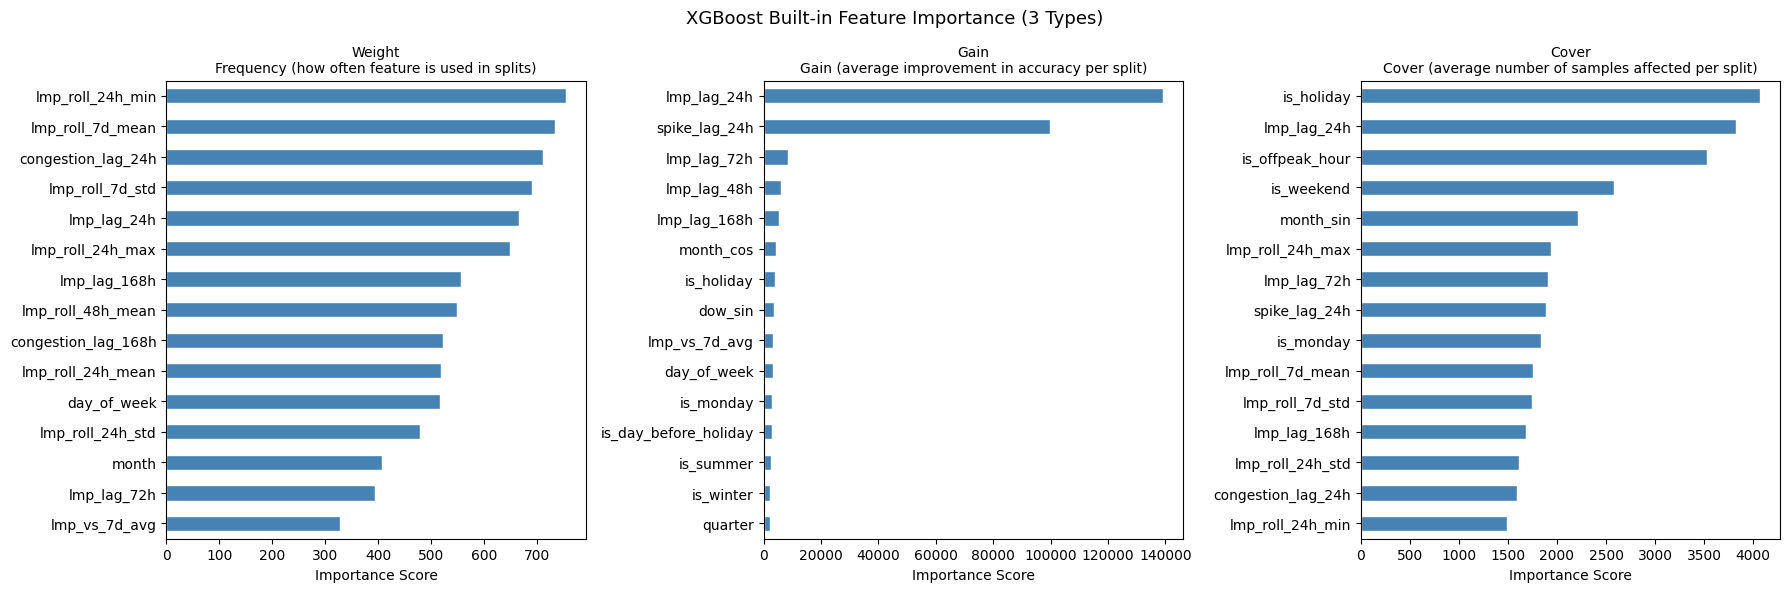

In [2]:
# --- Built-in XGBoost Importance ---

# XGBoost has 3 built-in importance types
importance_types = ['weight', 'gain', 'cover']
importance_labels = {
    'weight': 'Frequency (how often feature is used in splits)',
    'gain':   'Gain (average improvement in accuracy per split)',
    'cover':  'Cover (average number of samples affected per split)'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp_type in zip(axes, importance_types):
    imp = pd.Series(
        model.get_booster().get_score(importance_type=imp_type)
    ).sort_values(ascending=True).tail(15)  # Top 15

    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{imp_type.capitalize()}\n{importance_labels[imp_type]}',
                 fontsize=10)
    ax.set_xlabel('Importance Score')

plt.suptitle('XGBoost Built-in Feature Importance (3 Types)', fontsize=13)
plt.tight_layout()
plt.savefig('results/xgb_builtin_importance.png', dpi=150)
plt.show()

### Chart 1 — Built-in Importance (3 Types)
Notice the disagreement between the three panels:
**Weight (left)**: `lmp_roll_24h_min` used most frequently in splits — but frequency doesn't mean importance, just that it's a useful splitting point at many levels of the tree.
**Gain (middle)**: `lmp_lag_24h` and `spike_lag_24h` dominate massively — these two features produce the biggest accuracy improvements per split. This is the most meaningful of the three built-in types.
**Cover (right)**: `is_holiday` tops cover — it affects the most samples per split, acting as a high-level gate early in the trees (holiday vs normal day partitions the data broadly), with `lmp_lag_24h` close behind.
**The lesson**: Built-in importance types disagree with each other. This is exactly why SHAP is better — it gives one consistent, mathematically grounded answer.

Built-in importance has a flaw — it doesn't tell you direction or magnitude. SHAP fixes both.

In [3]:
# --- SHAP Values ---
# We compute exact TreeSHAP values on the test set.
#
# NOTE: shap 0.45.1's shap.TreeExplainer(model) can't parse XGBoost 3.x's
# serialized base_score (stored as a string like '[4.6E1]'), so we call
# XGBoost's built-in TreeSHAP via pred_contribs instead. It's the *same*
# Lundberg TreeSHAP algorithm shap.TreeExplainer would run, just invoked
# natively — and shap is still used below for the plots.

# Use a sample of 2000 rows for speed — still statistically representative.
# Seed the sample so the ranking below is reproducible across runs.
np.random.seed(42)
sample_idx  = np.random.choice(len(X_test), size=2000, replace=False)
X_sample    = X_test.iloc[sample_idx]

print("Calculating SHAP values... (takes ~30 seconds)")
booster      = model.get_booster()
_contribs    = booster.predict(xgb.DMatrix(X_sample), pred_contribs=True)
shap_values  = _contribs[:, :-1]   # drop the final column (bias / base value)
print(f"SHAP values shape: {shap_values.shape}")
print("Done.")

Calculating SHAP values... (takes ~30 seconds)


SHAP values shape: (2000, 33)
Done.


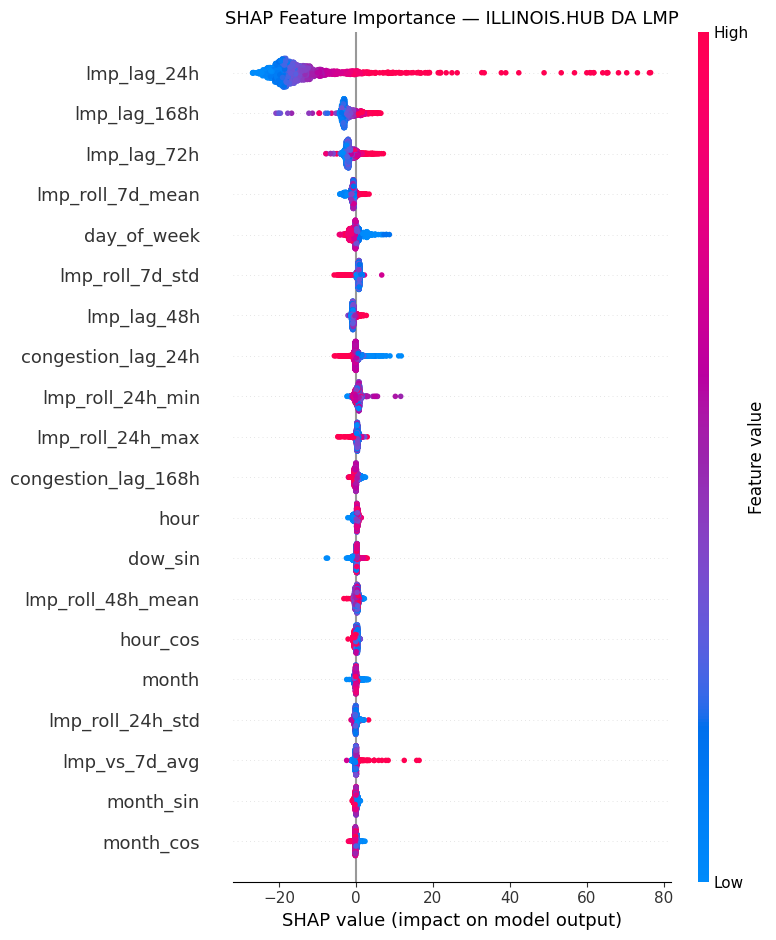

In [4]:
# --- SHAP Summary Plot ---

# Summary plot — the most important SHAP visualization
# Each dot = one prediction
# X axis = how much that feature pushed price up or down
# Color = feature value (red=high, blue=low)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURES,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — ILLINOIS.HUB DA LMP', fontsize=13)
plt.tight_layout()
plt.savefig('results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — SHAP Summary Plot (The Most Informative)
Read this carefully — each row is a feature, each dot is one prediction hour:

`lmp_lag_24h` **— Dominant, Massive Range**

- Red dots (high yesterday price) push predictions strongly to the right — by tens of $/MWh on the highest-price hours
- Blue dots (low yesterday price) push predictions left
- The dots stretch far to the right — those are the high-price and polar-vortex hours where yesterday's elevated price correctly signaled "today will also be expensive"
- Translation: Yesterday's price is by far the strongest signal your model uses — even more so now that training spans the high-volatility 2022 regime

`lmp_lag_168h` **— Strong but Narrower**

- Same direction as lag_24h but a much-compressed range
- Weekly seasonality working correctly

`day_of_week` **— Bidirectional**

- Red dots (high day number = weekend) push left (lower price)
- Blue dots (low day number = weekday) push right (higher price)
- This is exactly the weekday/weekend gap you saw in notebook 01 EDA

`congestion_lag_24h` **— Interesting Outliers**

- A few blue dots far left — yesterday's negative congestion correctly predicts lower prices today
- Confirms congestion signal has real predictive value despite being noisy

`month_sin` and `hour` **— Seasonal and Daily Patterns**

- Both show bidirectional effects
- Confirms the model learned the seasonal and daily curves from notebook 01

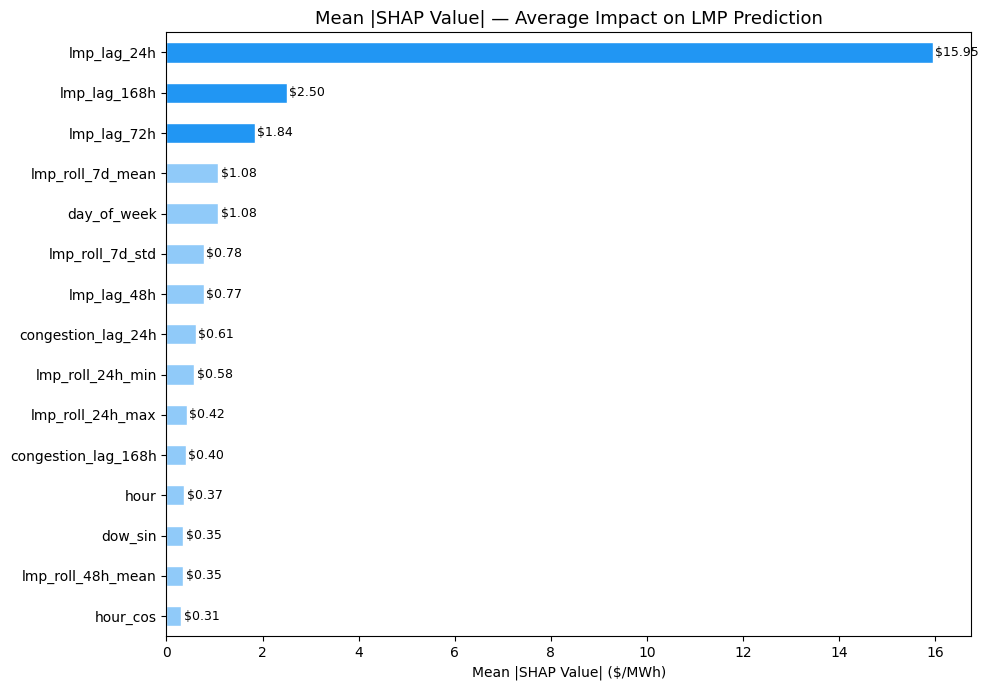

In [5]:
# SHAP Bar Plot (Mean Absolute Impact)

# Mean absolute SHAP value per feature
# Cleaner ranking than the dot plot
shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2196F3' if i >= len(shap_mean)-3 
          else '#90CAF9' for i in range(len(shap_mean))]
shap_mean.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Mean |SHAP Value| — Average Impact on LMP Prediction',
             fontsize=13)
ax.set_xlabel('Mean |SHAP Value| ($/MWh)')

# Add value labels
for i, (val, name) in enumerate(zip(shap_mean.values, shap_mean.index)):
    ax.text(val + 0.05, i, f'${val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/shap_bar.png', dpi=150)
plt.show()

### Chart 3 - SHAP Bar Plot (Clean Ranking)
```
#1  lmp_lag_24h       $15.95/MWh  ← ~6x more important than #2
#2  lmp_lag_168h      $2.50/MWh
#3  lmp_lag_72h       $1.84/MWh
#4  lmp_roll_7d_mean  $1.08/MWh
#5  day_of_week       $1.08/MWh
```
**The Answer to "What Drives Your Model?"**
**Price momentum dominates — overwhelmingly.** The top 3 features are all lagged LMP values, and `lmp_lag_24h` alone dwarfs everything else. The model is primarily saying "tomorrow's price will look a lot like recent prices, adjusted for day of week and season."

> Note: training on 2022–2023 (which includes the high-price 2022 regime) makes `lmp_lag_24h` an even stronger lever than it was on the 2-year data — when recent prices carry that much range, yesterday's level becomes the single most informative input.

The feature groups ranked by total SHAP impact:
|Group |Features in Top 15| Interpretation|
|------|------------------|---------------|
|Lag LMP| 4 features|Price momentum is #1 driver|
|Temporal|4 features|Hour, day, month patterns|
|Rolling stats| 5 features|Recent market context|
|Congestion lags|2 features|Transmission signal|

<Figure size 1000x500 with 0 Axes>

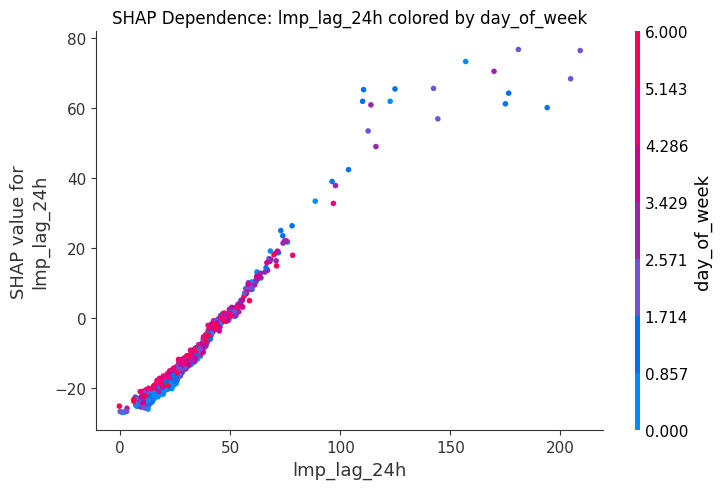

In [6]:
# --- One Final SHAP Plot: Dependence Plot ---
# This shows exactly HOW `lmp_lag_24h` affects predictions

plt.figure(figsize=(10, 5))
shap.dependence_plot(
    'lmp_lag_24h',
    shap_values,
    X_sample,
    interaction_index='day_of_week',
    show=False
)
plt.title("SHAP Dependence: lmp_lag_24h colored by day_of_week", fontsize=12)
plt.tight_layout()
plt.savefig('results/shap_dependence.png', dpi=150)
plt.show()

### Reading the SHAP Dependence Plot
**X-axis**: The actual value of `lmp_lag_24h` (yesterday's price, $/MWh)
**Y-axis**: How much that feature pushed today's prediction up or down
Color: Day of week (blue = Monday=0, red = Sunday=6)

### Three Distinct Regions:
**Region 1 — Low Prices (the dense cluster at left)**
- Tight, near-linear relationship — when yesterday was cheap, today is predicted cheap
- SHAP contribution stays in a modest band around zero
- Colors mixed evenly — day of week doesn't matter much when prices are normal
- Translation: In normal markets, yesterday's price is a reliable, stable signal

**Region 2 — Medium Prices (the steepening middle)**
- SHAP values climb sharply as yesterday's price rises
- This is the "elevated market" regime — prices above normal trigger a non-linear response
- The model has learned that an unusually high yesterday means something unusual is happening
- Translation: The relationship is non-linear — XGBoost correctly learned that high prices beget high prices more than proportionally

**Region 3 — Extreme Prices (the scattered dots at far right)**
- Wide spread of large positive SHAP values
- Those far-right points are the polar-vortex / spike hours, where yesterday's extreme price drives a large upward push
- Look at the coloring here: where weekday vs weekend points separate, it hints at a day-of-week interaction during extreme events

### The Interaction to Look For
The color pattern at the extreme end is where the interesting interaction lives:

If extreme-price weekend hours sit *higher* than extreme-price weekday hours, that reflects a real physical story — during events like a polar vortex, residential heating load dominates and doesn't fall on weekends the way industrial load does, so weekend extreme prices can be stickier. This kind of conditional, non-linear interaction is exactly what a tree model captures automatically and a simple linear model misses.